노드 수: 5020
평균 상관(이웃): 0.954
평균 상관(비이웃): 0.739


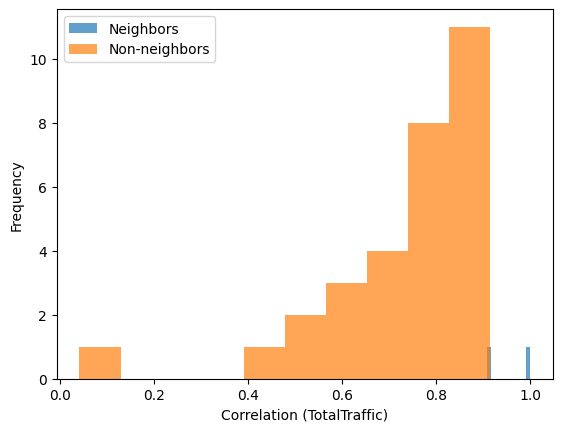

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 데이터 로드
X = np.load("/mnt/c/새 폴더/res/X_samples.npy")  # (S, N, T_in, F)
Y = np.load("/mnt/c/새 폴더/res/Y_samples.npy")  # (S, N, T_out, 2)
A = np.load("/mnt/c/새 폴더/res/adjacency_norm.npy")  # (N, N)

S, N, T_in, F = X.shape
print("노드 수:", N)

# 1) 한 노드의 series 가져오기 (TotalTraffic)
node_i = 100  # 예시
traffic_i = X[:, node_i, :, 0].reshape(-1)  # 모든 샘플 flatten (총 시계열로 보기)

# 2) 이웃 노드 vs 비이웃 노드
neighbors = np.where(A[node_i] > 0)[0]
non_neighbors = np.where(A[node_i] == 0)[0]

# 3) 상관계수 계산 (numpy.corrcoef)
corr_neighbors = []
corr_non_neighbors = []

for j in neighbors[:30]:  # 이웃 일부만
    traffic_j = X[:, j, :, 0].reshape(-1)
    c = np.corrcoef(traffic_i, traffic_j)[0,1]
    corr_neighbors.append(c)

for j in non_neighbors[:30]:  # 비이웃 일부만
    traffic_j = X[:, j, :, 0].reshape(-1)
    c = np.corrcoef(traffic_i, traffic_j)[0,1]
    corr_non_neighbors.append(c)

# 4) 평균 비교
print(f"평균 상관(이웃): {np.mean(corr_neighbors):.3f}")
print(f"평균 상관(비이웃): {np.mean(corr_non_neighbors):.3f}")

# 5) 시각화
plt.hist(corr_neighbors, alpha=0.7, label='Neighbors')
plt.hist(corr_non_neighbors, alpha=0.7, label='Non-neighbors')
plt.xlabel("Correlation (TotalTraffic)")
plt.ylabel("Frequency")
plt.legend()
plt.show()
